# Tissue Microarray Simulation and Core Separation Analysis

This notebook demonstrates the simulation of tissue microarray (TMA) arrays with realistic, irregular, and overlapping cores. It includes:

- Generation of synthetic TMA data with customizable parameters (core shape, size, density, irregularity, overlap, etc.)
- Extraction and visualization of specific tissue cores
- Anonymization of core identities for unbiased analysis
- Application of clustering methods (Gaussian Mixture, k-means, DBSCAN) to separate cores
- **Linear Discriminant Analysis (LDA): Ongoing improvements are being made to enhance separation accuracy. Current results are preliminary and further optimization is needed.**
- Quantitative evaluation of separation accuracy using true core identities
- Comparison of cell distribution fits (Poisson, negative binomial) within tissue punches

The workflow is designed for robust, publication-quality spatial analysis and benchmarking of unsupervised core separation strategies.

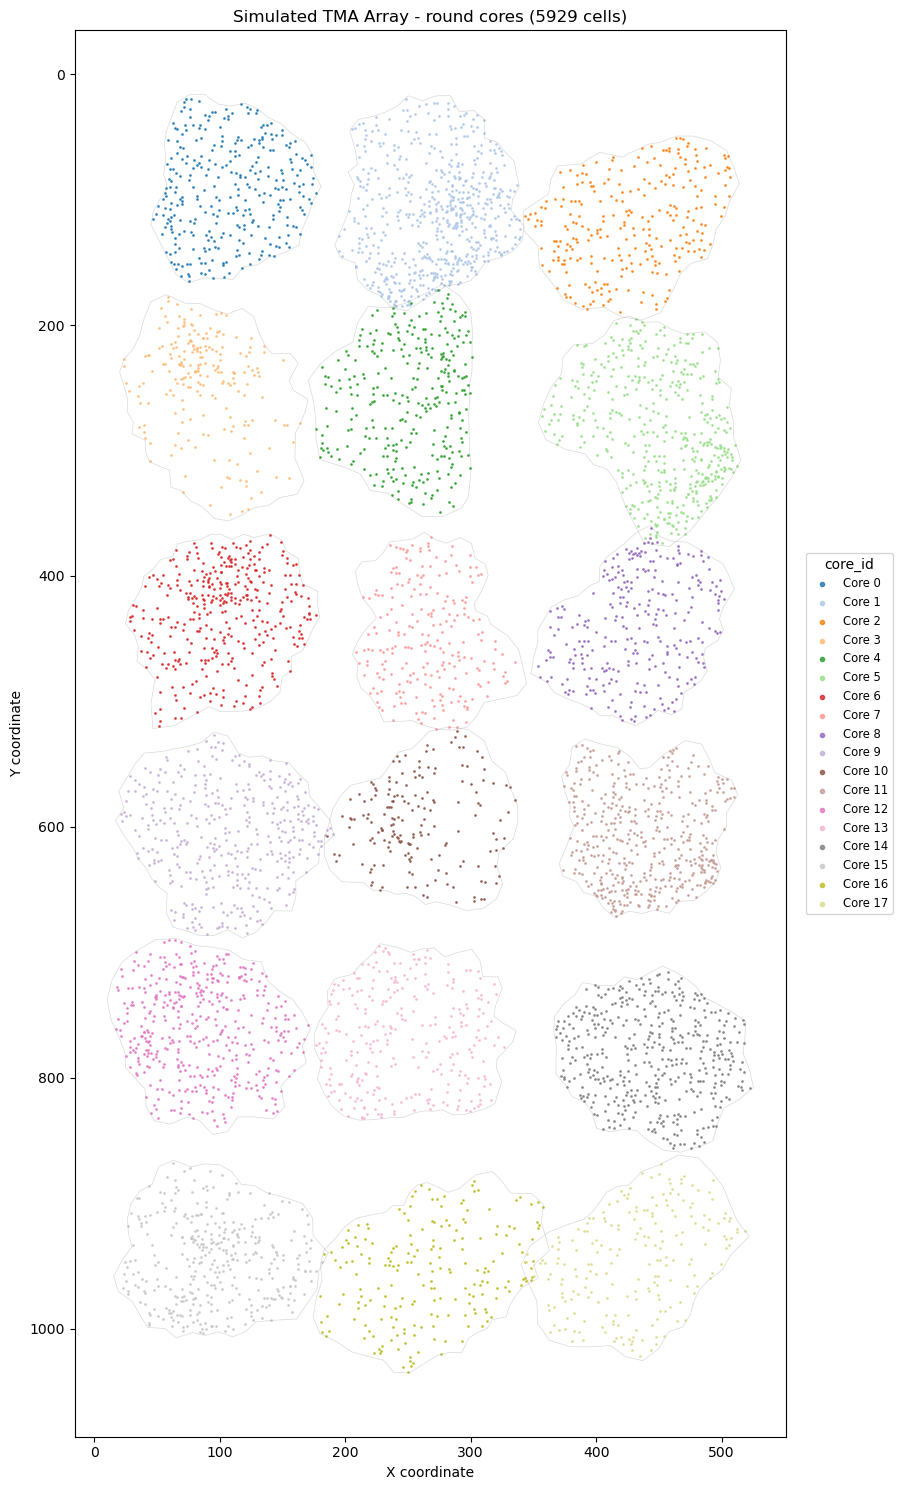

In [102]:
# Generate TMA with ROUND cores (realistic, messy)
adata_round = simulate_tma_array(
    n_rows=6,
    n_cols=3,
    core_shape='round',
    core_size=150,
    spacing=20,
    cell_density=0.015,
    irregularity=0.35,
    missing_cores=0.05,
    edge_core_prob=0.3,
    position_jitter=0.3,
    overlap_prob=0.2,
    n_genes=100,
    random_seed=42
)
plot_tma(adata_round, color_by='core_id')
adata_round.write_h5ad('round_tma.h5ad')

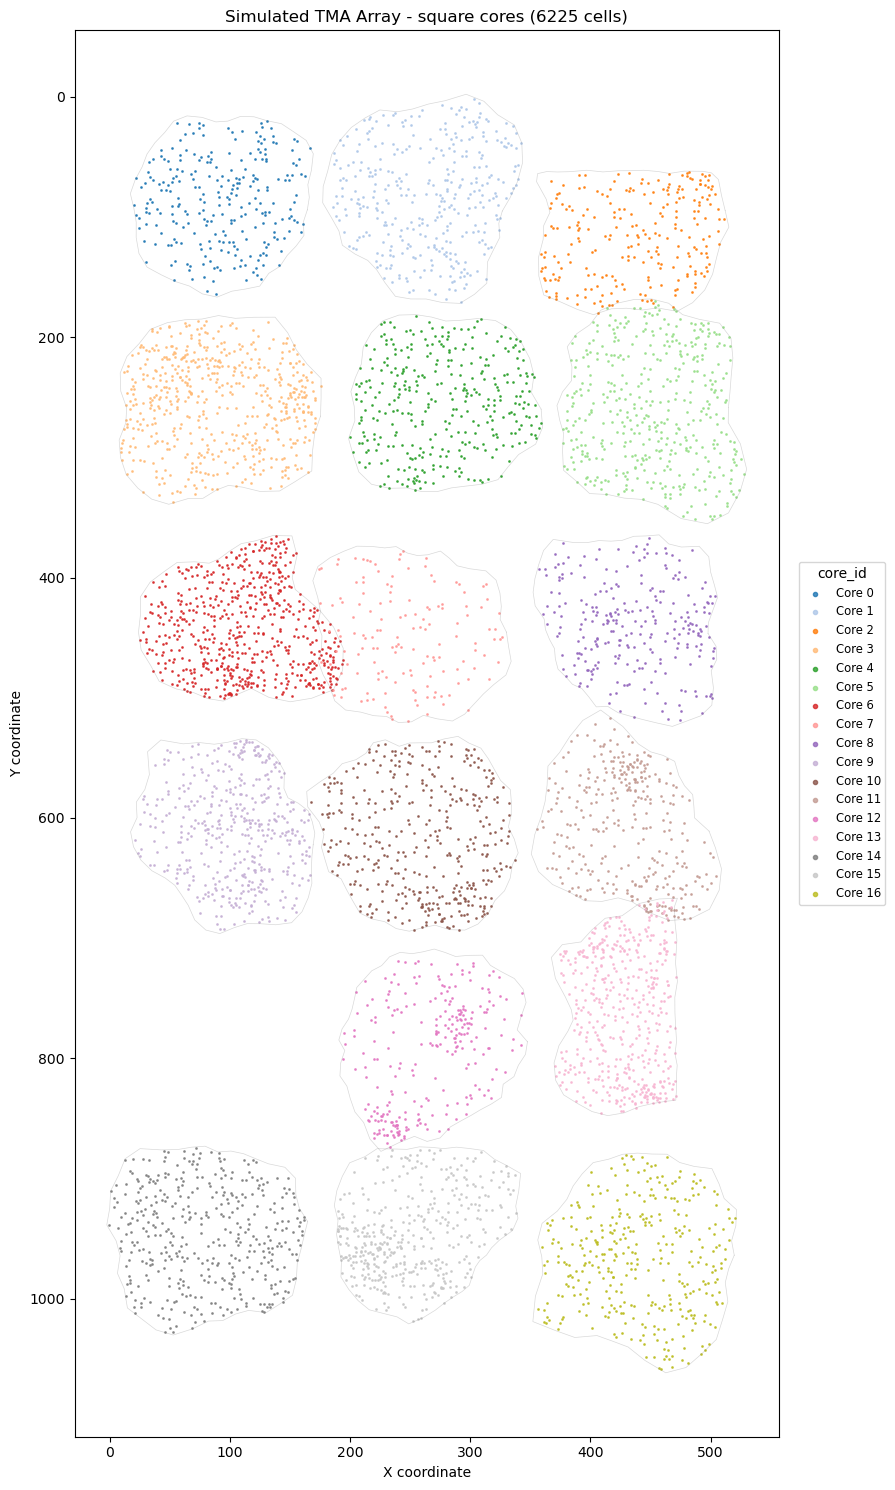

In [103]:
import importlib
import simulate_TMA
importlib.reload(simulate_TMA)

from simulate_TMA import simulate_tma_array, plot_tma

# Generate realistic TMA with SQUARE cores (messy, organic shapes)
adata = simulate_tma_array(
    n_rows=6,
    n_cols=3,
    core_shape='square',
    core_size=150,
    spacing=20,  # Reduced spacing for closer samples
    cell_density=0.015,
    irregularity=0.2,  # Higher for organic, messy shapes
    missing_cores=0.05,
    edge_core_prob=0.3,
    position_jitter=0.55,  # Offset from perfect grid
    overlap_prob=0.1,  # Some samples touch/overlap
    n_genes=100,
    random_seed=42
)
plot_tma(adata, color_by='core_id')
adata.write_h5ad('square_tma.h5ad')

Unique core IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Extracted 745 cells from cores [6, 7]
Saved to cores_6_7.h5ad


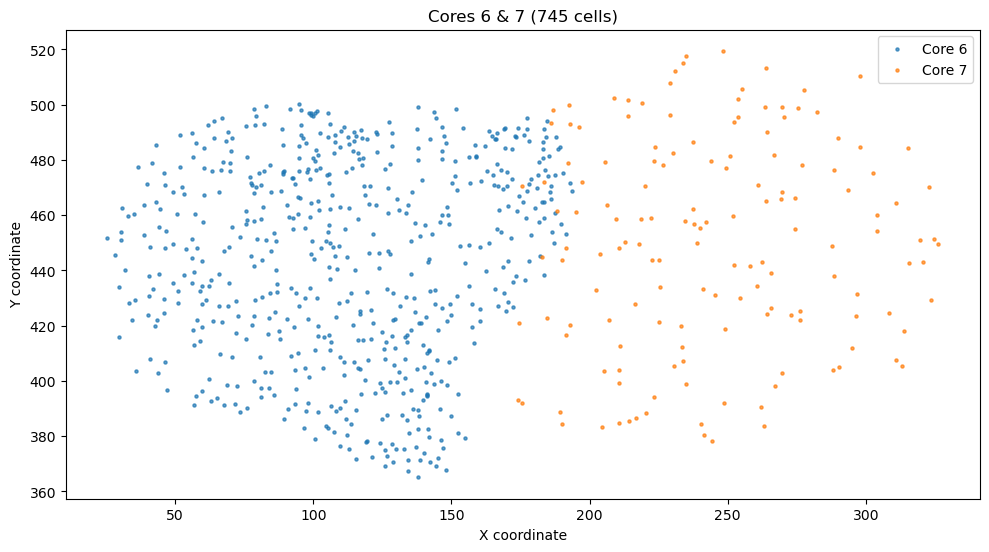

In [104]:
# Extract cores 6 and 7 into a new file
print("Unique core IDs:", adata.obs['core_id'].unique().tolist())
cores_to_extract = [6, 7]
mask = adata.obs['core_id'].isin(cores_to_extract)
adata_subset = adata[mask].copy()
print(f"Extracted {adata_subset.n_obs} cells from cores {cores_to_extract}")
adata_subset.write_h5ad('cores_6_7.h5ad')
print("Saved to cores_6_7.h5ad")

# Plot only cores 6 and 7 (zoomed in)
import matplotlib.pyplot as plt
import json
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
coords = adata_subset.obsm['spatial']
colors = ['#1f77b4', '#ff7f0e']

for i, core_id in enumerate(cores_to_extract):
    core_mask = adata_subset.obs['core_id'] == core_id
    core_coords = coords[core_mask]
    ax.scatter(core_coords[:, 0], core_coords[:, 1], s=5, c=colors[i], label=f'Core {core_id}', alpha=0.7)

ax.set_facecolor('white')
ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title(f'Cores 6 & 7 ({adata_subset.n_obs} cells)')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

LDA accuracy: 97.32% | use_density=False | kde_bandwidth=30 | solver=lsqr | shrinkage=auto
LDA accuracy: 98.52% | use_density=True | kde_bandwidth=20 | solver=lsqr | shrinkage=None


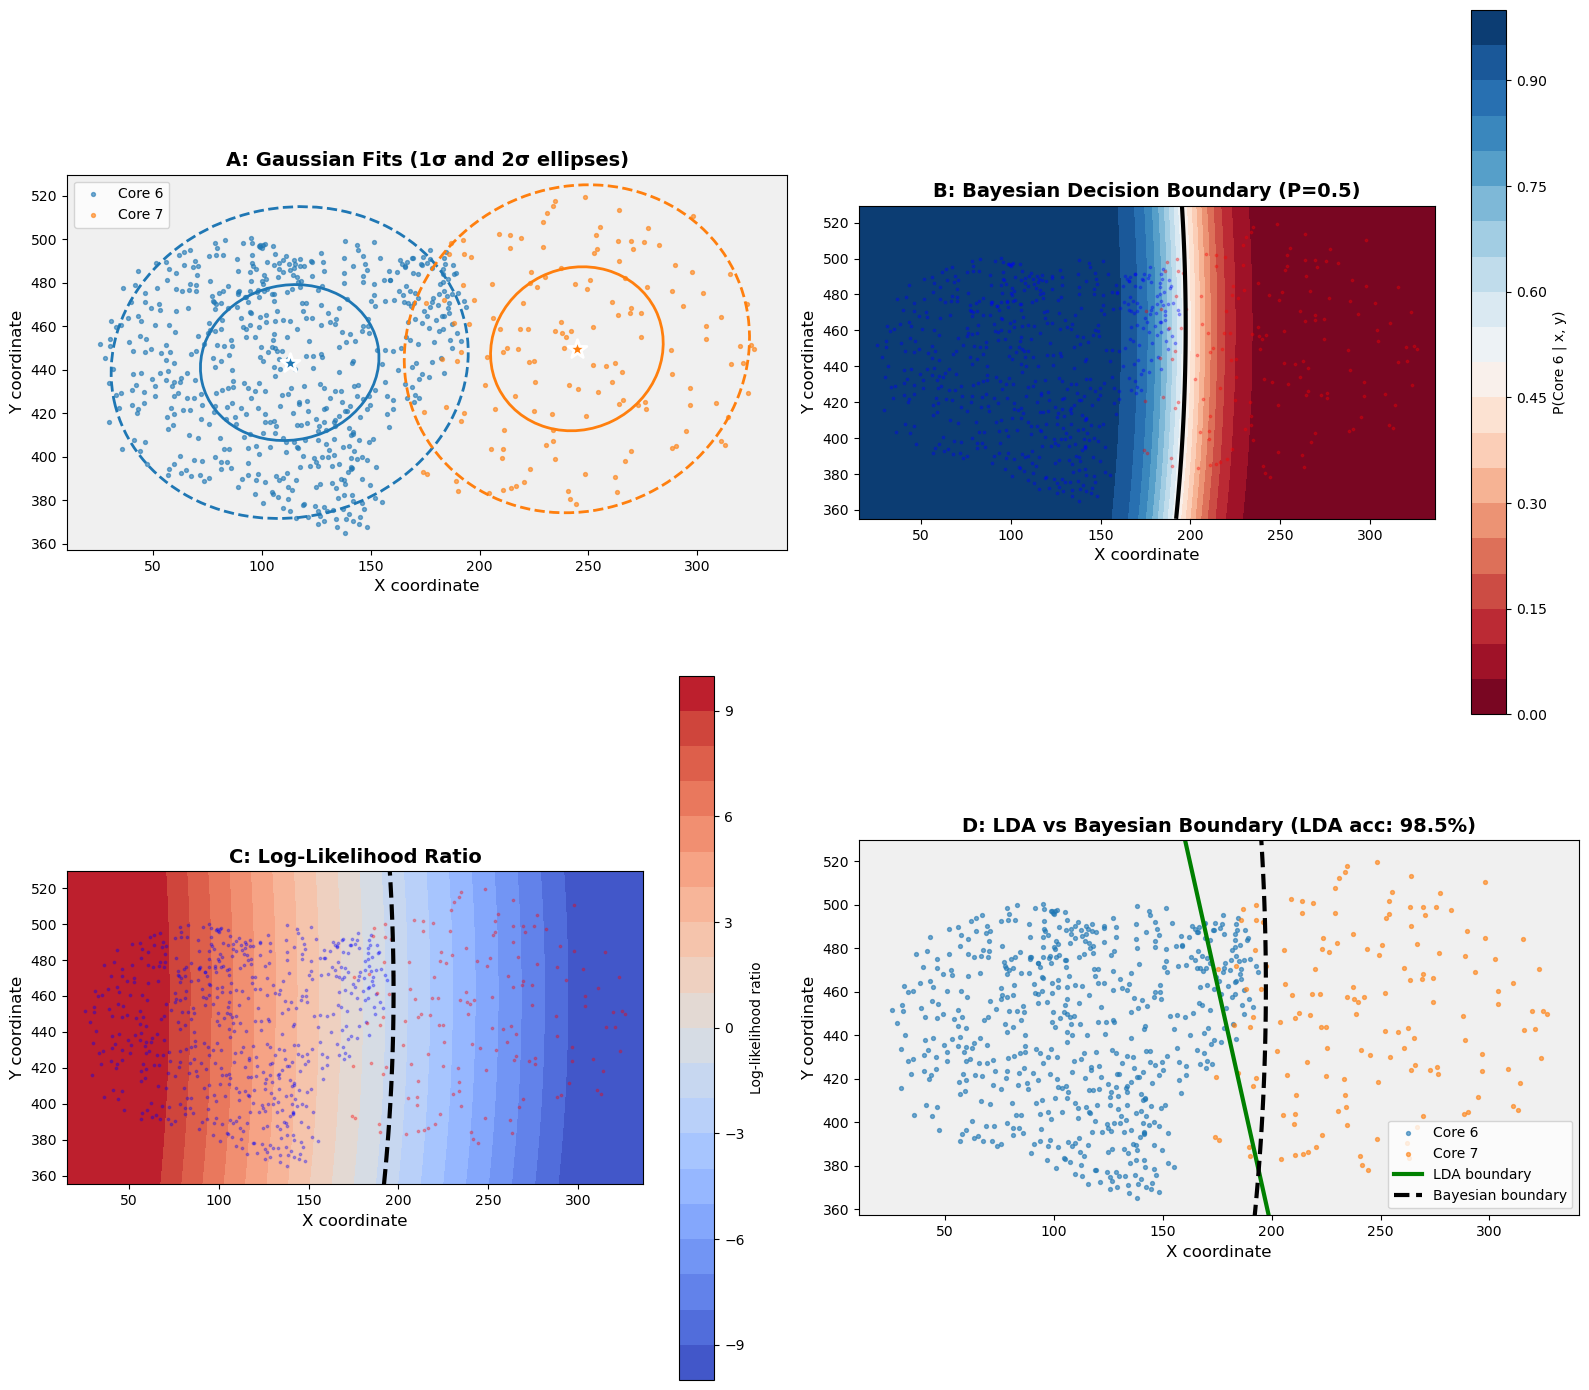

✓ Saved distribution plot to cores_6_7_lda_tuned.png

CORE SEPARATION ANALYSIS SUMMARY

Cores: 6 and 7
  Core 6: 596 cells
  Core 7: 149 cells

Gaussian Distribution Fits:
  Core 6 centroid: (112.78, 443.28)
  Core 7 centroid: (244.72, 449.62)

LDA Boundary:
  Equation: 0.976043x + 0.217575y + -271.604206 = 0
  Accuracy: 98.52%



In [105]:
# Use LDA to separate cores 6 and 7 with fine-tuned options
import importlib
import LDA
importlib.reload(LDA)

from LDA import CoreSeparator
separator = CoreSeparator(adata_subset)
# Try different settings for best accuracy
# Example: no density, higher bandwidth, regularization
separator.fit_lda(use_density=False, kde_bandwidth=30, lda_solver='lsqr', lda_shrinkage='auto')
separator.plot_distributions(save_path='cores_6_7_lda_tuned.png')
separator.summary()
# Note: valid LDA solvers are 'lsqr', 'svd', 'eigen'. Do not use 'auto'.

In [106]:
# Save cores 6 & 7 to a new file with true identity removed
adata_subset_noid = adata_subset.copy()
if 'core_id' in adata_subset_noid.obs:
    adata_subset_noid.obs = adata_subset_noid.obs.drop(columns=['core_id'])
adata_subset_noid.write_h5ad('cores_6_7_noid.h5ad')
print("Saved to cores_6_7_noid.h5ad (core_id removed)")

Saved to cores_6_7_noid.h5ad (core_id removed)


LDA accuracy: 96.38% | use_density=True | kde_bandwidth=20 | solver=lsqr | shrinkage=None
LDA accuracy: 96.38% | use_density=True | kde_bandwidth=20 | solver=lsqr | shrinkage=None


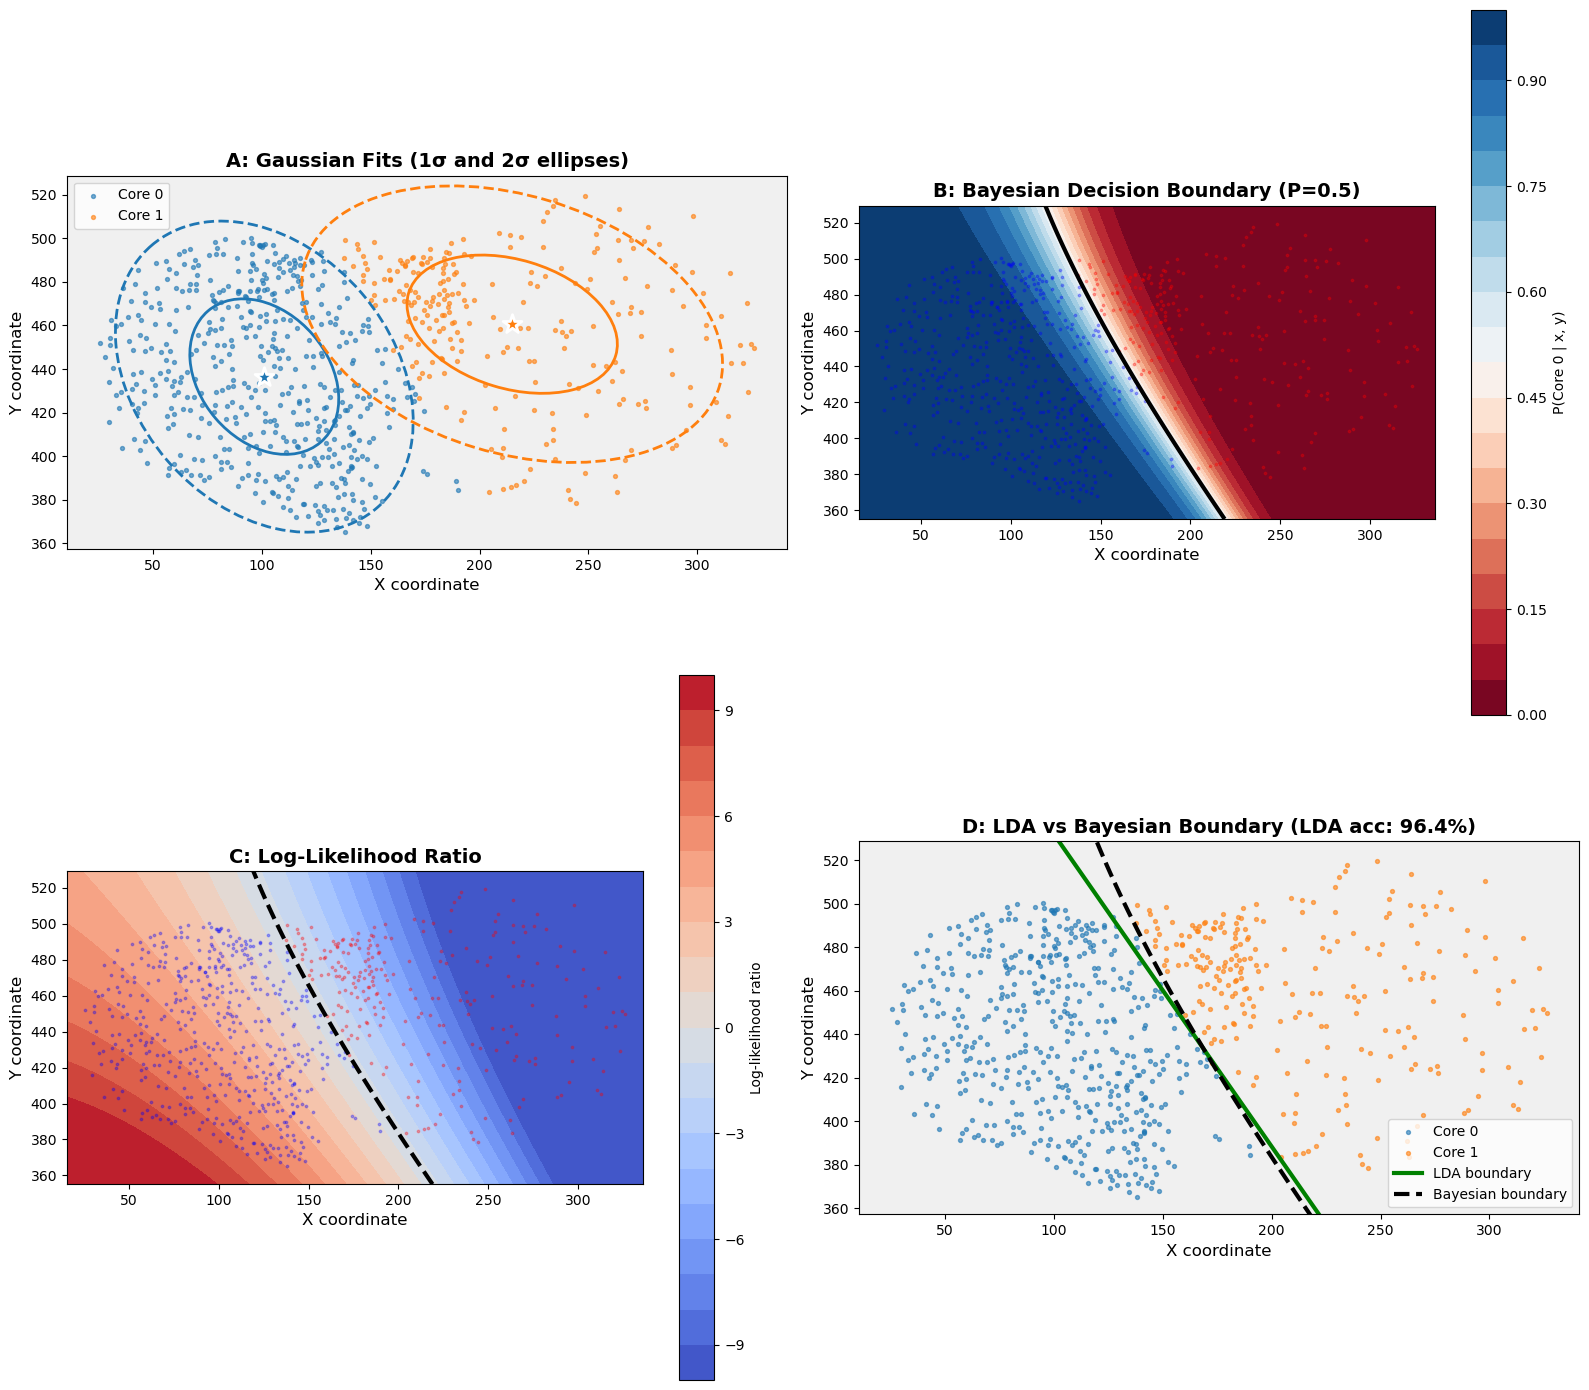

✓ Saved distribution plot to cores_6_7_noid_lda.png

CORE SEPARATION ANALYSIS SUMMARY

Cores: 0 and 1
  Core 0: 496 cells
  Core 1: 249 cells

Gaussian Distribution Fits:
  Core 0 centroid: (101.10, 436.50)
  Core 1 centroid: (214.99, 460.59)

LDA Boundary:
  Equation: 0.820317x + 0.571909y + -386.174677 = 0
  Accuracy: 96.38%



In [107]:
# Use LDA to test separation of the two cores in the anonymized file
import scanpy as sc
import LDA
import importlib
importlib.reload(LDA)

adata_noid = sc.read_h5ad('cores_6_7_noid.h5ad')

# Since core_id is removed, use Gaussian fit (GMM) on spatial coordinates as a proxy for core identity
from sklearn.mixture import GaussianMixture
coords = adata_noid.obsm['spatial']
gmm = GaussianMixture(n_components=2, random_state=42).fit(coords)
labels_gmm = gmm.predict(coords)
adata_noid.obs['core_id'] = labels_gmm

# Now use LDA to test separation
from LDA import CoreSeparator
separator_noid = CoreSeparator(adata_noid)
separator_noid.fit_lda()
separator_noid.plot_distributions(save_path='cores_6_7_noid_lda.png')
separator_noid.summary()

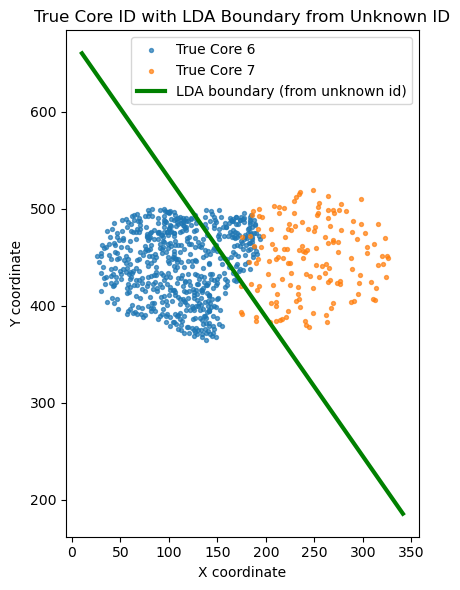

In [108]:
# Plot the true core identity and overlay the LDA boundary from the anonymized (unknown id) separation
import matplotlib.pyplot as plt
import numpy as np

# Load original data with true core_id
adata_true = adata_subset  # already loaded earlier with true core_id
coords_true = adata_true.obsm['spatial']
core_ids = adata_true.obs['core_id'].values

# Load LDA boundary from separator_noid
lda_result = separator_noid.results['lda']
a, b, c = lda_result['a'], lda_result['b'], lda_result['c']

# Plot true core ids
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e']
for i, core_id in enumerate(np.unique(core_ids)):
    mask = core_ids == core_id
    ax.scatter(coords_true[mask, 0], coords_true[mask, 1], s=8, c=colors[i], label=f'True Core {core_id}', alpha=0.7)

# Overlay LDA boundary from unknown id
xlim = ax.get_xlim()
x_range = np.array(xlim)
if abs(b) > 1e-10:
    y_lda = (-a * x_range - c) / b
    ax.plot(x_range, y_lda, 'g-', linewidth=3, label='LDA boundary (from unknown id)')

ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
ax.set_title('True Core ID with LDA Boundary from Unknown ID')
ax.legend()
ax.set_facecolor('white')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()